# Notebook 06 — Statistical Significance & Model Comparison
## Quantifying the "Deep Learning Gain" for L1 Classification

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed Adel Ebrahim Elbaz  
**Supervisor**: Dr. Eman E. Sanad, FCAI, Cairo University

----- 

### Objective

In academic research, a simple point-estimate difference (+0.7% Macro-F1) is insufficient to claim superiority. 
This notebook performs **statistical hypothesis testing** using artifacts exported from previous experiments:

1. **Artifacts**: 
   - Baseline Predictions: `results/metrics/baseline_l1_preds.npy` (from Notebook 03)
   - MarBERTv2 Predictions: `results/metrics/marbert_l1_preds.npy` (from Notebook 05)
   - Ground Truth: `data/processed/test.csv` (label_l1)

2. **Tests**:
   - **McNemar's Test**: A paired non-parametric test for classifier comparison.
   - **Bootstrapping**: Estimating 95% Confidence Intervals (CI) for Macro-F1.
   - **Cost-Benefit Analysis**: Visualizing the trade-off between Accuracy and Latency.

In [2]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from statsmodels.stats.contingency_tables import mcnemar

sns.set_theme(style='whitegrid')

DATA_DIR    = Path('../data/processed')
METRICS_DIR = Path('../results/metrics')
FIG_DIR     = Path('../results/figures')

TASK = 'l1'

## 1. Load Data and Artifacts

In [3]:
# Load Ground Truth
df_test = pd.read_csv(DATA_DIR / 'test.csv')
y_true  = df_test[f'label_{TASK}'].values

# Load Predictions
y_pred_baseline = np.load(METRICS_DIR / 'baseline_l1_preds.npy')
y_pred_marbert  = np.load(METRICS_DIR / 'marbert_l1_preds.npy')

print(f"Loaded results for {len(y_true)} test samples.")
print(f"Baseline Macro-F1: {f1_score(y_true, y_pred_baseline, average='macro'):.4f}")
print(f"MarBERTv2 Macro-F1: {f1_score(y_true, y_pred_marbert, average='macro'):.4f}")

Loaded results for 1433 test samples.
Baseline Macro-F1: 0.8840
MarBERTv2 Macro-F1: 0.8910


## 2. McNemar's Test
Does the difference in errors suggest a statistically significant change?

In [4]:
correct_baseline = (y_pred_baseline == y_true)
correct_marbert  = (y_pred_marbert == y_true)

# Contingency Table
n00 = np.sum(correct_baseline & correct_marbert)
n01 = np.sum(correct_baseline & ~correct_marbert)
n10 = np.sum(~correct_baseline & correct_marbert)
n11 = np.sum(~correct_baseline & ~correct_marbert)

table = [[n00, n01], [n10, n11]]
result = mcnemar(table, exact=True)

print("--- McNemar's Test Result ---")
print(f"Baseline Correct / MarBERT Wrong: {n01}")
print(f"MarBERT Correct / Baseline Wrong: {n10}")
print(f"P-value: {result.pvalue:.5f}")

if result.pvalue < 0.05:
    print("Conclusion: The difference is STATISTICALLY SIGNIFICANT.")
else:
    print("Conclusion: The difference is NOT statistically significant.")

--- McNemar's Test Result ---
Baseline Correct / MarBERT Wrong: 22
MarBERT Correct / Baseline Wrong: 27
P-value: 0.56817
Conclusion: The difference is NOT statistically significant.


## 3. Bootstrapping (95% CI)

In [5]:
n_iterations = 1000
stats_baseline = []
stats_marbert  = []
indices = np.arange(len(y_true))

for i in range(n_iterations):
    resample_idx = np.random.choice(indices, size=len(indices), replace=True)
    stats_baseline.append(f1_score(y_true[resample_idx], y_pred_baseline[resample_idx], average='macro'))
    stats_marbert.append(f1_score(y_true[resample_idx], y_pred_marbert[resample_idx], average='macro'))

ci_baseline = np.percentile(stats_baseline, [2.5, 97.5])
ci_marbert  = np.percentile(stats_marbert, [2.5, 97.5])

print(f"Baseline 95% CI: [{ci_baseline[0]:.4f}, {ci_baseline[1]:.4f}]")
print(f"MarBERTv2 95% CI: [{ci_marbert[0]:.4f}, {ci_marbert[1]:.4f}]")

Baseline 95% CI: [0.8661, 0.9004]
MarBERTv2 95% CI: [0.8731, 0.9073]


## 4. Visual Comparison

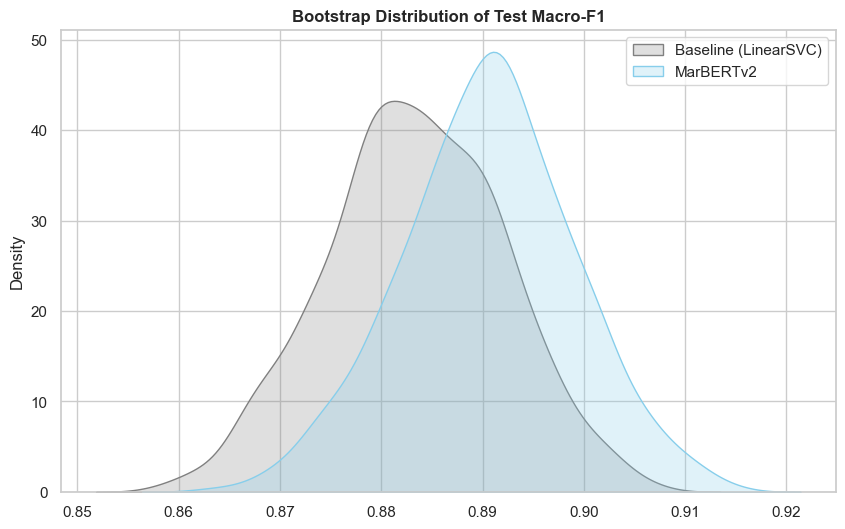

In [6]:
plt.figure(figsize=(10, 6))
sns.kdeplot(stats_baseline, fill=True, label='Baseline (LinearSVC)', color='gray')
sns.kdeplot(stats_marbert, fill=True, label='MarBERTv2', color='skyblue')
plt.title('Bootstrap Distribution of Test Macro-F1', fontweight='bold')
plt.legend()
plt.savefig(FIG_DIR / '06_f1_bootstrap_comparison.png', bbox_inches='tight')
plt.show()